In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
from scipy.ndimage import sobel, uniform_filter1d
import scipy
import xarray as xr

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_66993/378018370.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
mission_32 = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
mission_31 = 'ArgusFF_20211013T163100Z_RectifiedVideo.avi'


In [4]:
def make_timetack(dir, file, stop=np.inf):
    cap = cv2.VideoCapture(os.path.join(dir, file))
    N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

    # NOTE: We're downsampling in along-shore to 10m
    skip = 1
    timestack = np.zeros((min(N, stop), H//skip, W))
    # stop = 300
    # stop = np.inf

    for i in tqdm(range(min(N, stop))):
        _, frame = cap.read()
        timestack[i] = frame[::skip, :, 0]

    cap.release()
    cv2.destroyAllWindows()
    return timestack

In [5]:
file = mission_32

timestack = make_timetack(dir, file, 300)

cap = cv2.VideoCapture(os.path.join(dir, file))

N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = 100
NFRAMES = FPS * SECONDS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 440.67it/s]


In [6]:
def find_peaks(timestack, c=5):
    peaks = []
    for i in tqdm(range(0, 1600)):
        p = np.argsort(
                sobel(timestack[:, i, :].T),
            axis=0)[::-1][:c]
        peaks.append(
            np.array(p)
        )

        # sb = sobel(timestack[:, i, :])
        # p = []
                
        # for j in range(0, sb.shape[0]):
        #     pks, props = scipy.signal.find_peaks(
        #             sb[j, :], height=0
        #         )
        #     if(len(pks)>=c):
        #         p.append(pks[np.argsort(props['peak_heights'][::-1])][:c])
        #     else:
        #         pks = np.concatenate([np.argsort(props['peak_heights'][::-1]), [-1]*int(c-len(pks))])
        #         p.append(pks)
        # peaks.append(
        #     np.array(p).T
        # )
    peaks = np.array(peaks)
    return peaks    

def filter_peaks(peaks, c=5, min_samples=None):
        if min_samples is None:
            min_samples = 2*c
        labels = []
        filtered_peaks = []
        for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
            X = np.array([np.array([np.arange(peaks.shape[-1])]*c).flatten(), peaks[i][:c, :].flatten()])
            clustering = DBSCAN(eps=4, min_samples=min_samples).fit(X.T)
            l = clustering.labels_
            filtered_peaks.append(X[:, l>=0])
            labels.append(l[l>=0])

        return filtered_peaks, labels
    
def count_breakers(peaks, c=5):
    filtered_peaks = []
    for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
        X = np.array([np.array([np.arange(peaks.shape[-1])]*c).flatten(), peaks[i][:c, :].flatten()])
        filtered_peaks.append(X)

    return filtered_peaks

def count_filtered(filtered_peaks):
    count = np.zeros((1600, 500))
    for along, pks in enumerate(filtered_peaks):
        for t, cross in pks.T:
            count[along, cross] +=1
    return count

In [7]:
def original_pipeline(timestack):
    def find_peaks(timestack, c=5):
        peaks = []
        for i in tqdm(range(0, 1600)):
            p = np.argsort(
                    sobel(timestack[:, i, :].T),
                axis=0)[::-1][:c]
            peaks.append(
                np.array(p)
            )

        peaks = np.array(peaks)
        return peaks    

    def filter_peaks(peaks, c=5, min_samples=None):
        if min_samples is None:
            min_samples = 2*c
        labels = []
        filtered_peaks = []
        for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
            X = np.array([np.array([np.arange(peaks.shape[-1])]*c).flatten(), peaks[i][:c, :].flatten()])
            clustering = DBSCAN(eps=4, min_samples=min_samples).fit(X.T)
            l = clustering.labels_
            filtered_peaks.append(X[:, l>=0])
            labels.append(l[l>=0])

        return filtered_peaks, labels
    
    def count_filtered(filtered_peaks):
        count = np.zeros((1600, 500))
        for along, pks in tqdm(enumerate(filtered_peaks)):
            for t, cross in pks.T:
                count[along, cross] +=1
        return count
   
    return count_filtered(filter_peaks(find_peaks(timestack))[0])

In [8]:
class new_pipeline:
    
    def __init__(self, timestack):
        self.timestack = timestack

    def __call__(self):
        peaks = self.find_peaks(self.timestack)
        filtered_peaks, l = self.filter_peaks(peaks, self.timestack.shape[0], 5, 7)
        count = self.count_peaks(filtered_peaks, self.timestack.shape[1:])
        return count, filtered_peaks, peaks
    
    '''timestack is of dimension [time, cross-shore, along-shore]'''
    @staticmethod
    def find_peaks(timestack, c=5):
        '''Iterate a timestack for every cross-shore pixel, sobel filter the mean timetack, 
           and then pick out the brightest pixels where there's a peak in gradient gradient'''
        peaks = []
        for i in tqdm(range(0, 1600)):
            # Subtract the mean to remove bright streaks on shore & attempt to normalize for (stationary) glare
            # #TODO(@mleclair) Maybe this should actually the moving average
            diff = timestack[:, i, :]-timestack[:, i, :].mean(0)
            sb = sobel(diff)
            p = []
            for j in range(0, sb.shape[0]):
                pks, props = scipy.signal.find_peaks(
                        sb[j, :], height=25
                    )
                
                peaks_sorted_by_brightness = pks[np.argsort(diff[j, :][pks])[::-1]]
                
                if(len(pks)>=c):
                    p.append(peaks_sorted_by_brightness[:c])
                    
                else:
                    # Fill any missing peaks with -1 for consistent dimensions
                    p.append(np.concatenate([peaks_sorted_by_brightness, [-1]*int(c-len(pks))]))
                    
            peaks.append(
                    np.array(p).T
                )
        return np.array(peaks) # [cross-shore location, c, time]

    @staticmethod
    def filter_peaks(peaks, time_dim, c=5, min_samples=None):
        '''For each cross-shore transect DBSCAN to identify coherent waves'''
        if min_samples is None:
            min_samples = int(1.5*c)
        labels = []
        filtered_peaks = []
        cross_shore_transects = peaks.shape[0]
        for i in tqdm(range(cross_shore_transects)):
            X = np.array(
                [np.array([np.arange(time_dim)]*c).flatten(), 
                 peaks[i][:c, :].flatten()])

            clustering = DBSCAN(eps=4, min_samples=min_samples).fit(X.T)
            l = clustering.labels_
            l = l.reshape(c, -1)
            fp = peaks[i][:c, :]
            fp[l<0] = -1
            if len(fp>=c):
                filtered_peaks.append(fp)
            else:
                filtered_peaks.append(np.concatenate([fp, [-1] * int(c-len(fp))]))

        
        return np.array(filtered_peaks), labels # [cross-shore transects, peaks, time], labels
    
    @staticmethod
    def count_breakers(peaks, c=5):
        filtered_peaks = []
        for i in tqdm(range(len(peaks))): # Iterating over alongshore locations
            X = np.array([np.array([np.arange(peaks.shape[-1])]*c).flatten(), peaks[i][:c, :].flatten()])
            filtered_peaks.append(X)

        return filtered_peaks
    
    @staticmethod
    def count_peaks(filtered, image_shape):
        count = np.zeros(image_shape)
        for i in range(filtered.shape[0]):
            for j in range(filtered.shape[2]):
                idx = filtered[i, :, j][filtered[i, :, j]>=0]
                count[i, idx] += 1
        return count


In [14]:
def plot_timestack(timestack, peaks, time=(0, -1), along_shore=500):
    times = np.arange(timestack.shape[0])[time[0]: time[1]]
    plt.imshow(timestack[times, along_shore, :].T)
    
    for i in range(peaks.shape[1]):
        plt.scatter(times, peaks[along_shore, i, times], c=np.zeros_like(times) + i/peaks.shape[1], s=4, cmap='jet', vmin=0, vmax=1, alpha=0.75)
    plt.colorbar()
    
def plot_peaks(timestack, peaks, time=0, c=5):
    plt.imshow(timestack[time, ...].T)
    for i in range(c-1):
        p = peaks[:, i, time]
        plt.scatter(
            np.arange(1600)[p>0], 
            p[p>0],
            # c=np.arange(c).tolist()[::-1] * 1600,
            s=1,
            # cmap='Reds'
        )
    
def plot_all_peaks(timestack, peaks, time=0,):
    plt.imshow(timestack[time, ...].T)
    for count in range(peaks.shape[1]-1):
        for time in range(peaks.shape[2]-1):
            p = peaks[:, count, time]            
            plt.scatter(
                np.arange(1600)[p>0], 
                p[p>0],
                # c=np.arange(c).tolist()[::-1] * 1600,
                s=1,
                # cmap='Reds'
            )
            
def draw_peaks(image, peaks):
    image = cv2.merge((image, image, image))
 
    for i in range(peaks.shape[1]):
        for x, y, in zip(peaks[:, i], np.arange(peaks.shape[0])):
            if x == -1:
                continue
            # image = cv2.circle(image, (x, y), int((peaks.shape[1] - c + 1)//2), (255, 0, c * 25), -1)
            image = cv2.circle(image, (x, y), 3, (255, 0, 0), -1)

    return image.astype(np.uint8)

1.92mb per timestack


100%|██████████| 1600/1600 [00:01<00:00, 811.79it/s]
120it [00:01, 66.70it/s]


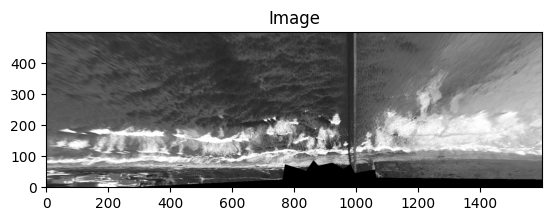

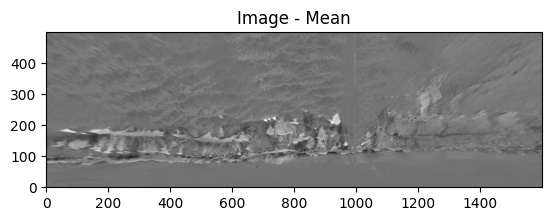

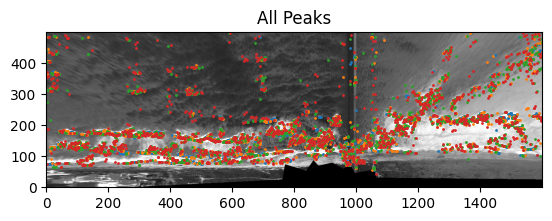

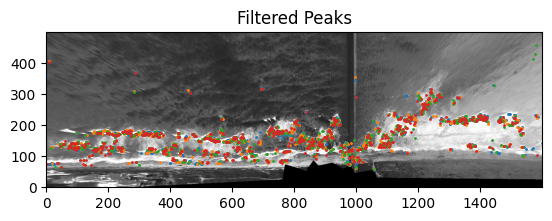

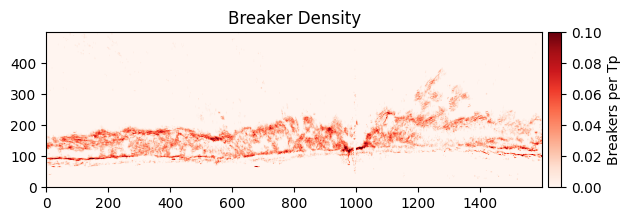

In [17]:
timestack = make_timetack(dir, mission_31, 120)
c=5
time = 50
plt.imshow((timestack[time, ...]).T)
plt.title('Image')
plt.figure()
plt.imshow((timestack[time, ...] - timestack.mean(0)).T)
plt.title('Image - Mean')
plt.figure()
peaks = new_pipeline.find_peaks(timestack, c)
plot_peaks(timestack, peaks, time, c)
plt.title('All Peaks')
plt.figure()
plt.title('Filtered Peaks')
filtered, l = new_pipeline.filter_peaks(peaks, timestack.shape[0], c, 7)
plot_peaks(timestack, filtered, time, c)
fig, ax = plt.subplots(1,1)
count = new_pipeline.count_peaks(filtered, timestack.shape[1:])
im = plt.imshow(count.T/120, vmax=1/10, cmap='Reds')
plt.title('Breaker Density')
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax, label='Breakers per Tp')
fname = 'frf_meeting_breakers.mp4'
out = cv2.VideoWriter(fname, cv2.VideoWriter_fourcc(*'avc1'), FPS*5, (H,W))
c=1
for i, (frame, peak) in tqdm(enumerate(zip(timestack, filtered[:, :, :].T))):
    f = np.flip(np.swapaxes(draw_peaks(frame, peak.T), 0, 1), 0)
    out.write(f)
        
out.release()
cv2.destroyAllWindows()


1.92mb per timestack


100%|██████████| 1600/1600 [00:01<00:00, 826.01it/s]


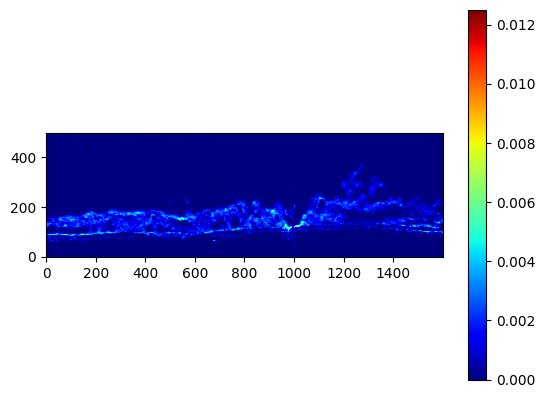

In [102]:
timestack = make_timetack(dir, mission_31, 1200)

cap = cv2.VideoCapture(os.path.join(dir, mission_31))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS = 2
SECONDS = N / FPS
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
cap.release()
cv2.destroyAllWindows()

count31_60, filtered, peaks = new_pipeline(timestack[:120, ...])()
# del timestack 
plt.imshow(count31_60.T/SECONDS, cmap='jet', vmin=0, vmax=1/80)
plt.colorbar()

Text(0.5, 1.0, 'Change in # Breakers detected per second New - Old (index vs peak finding) [60s]')

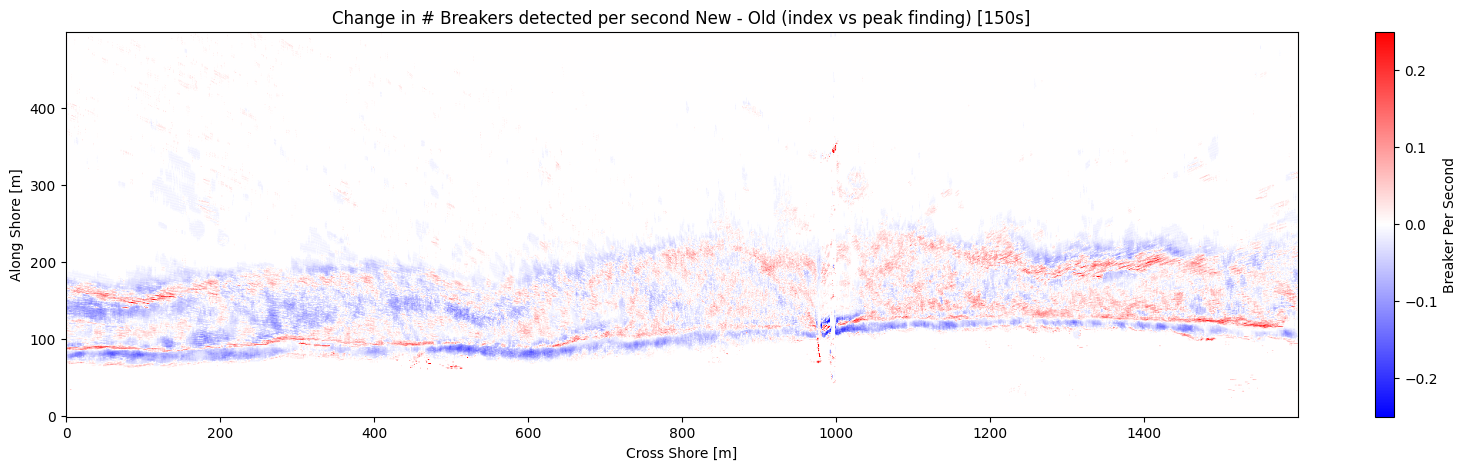

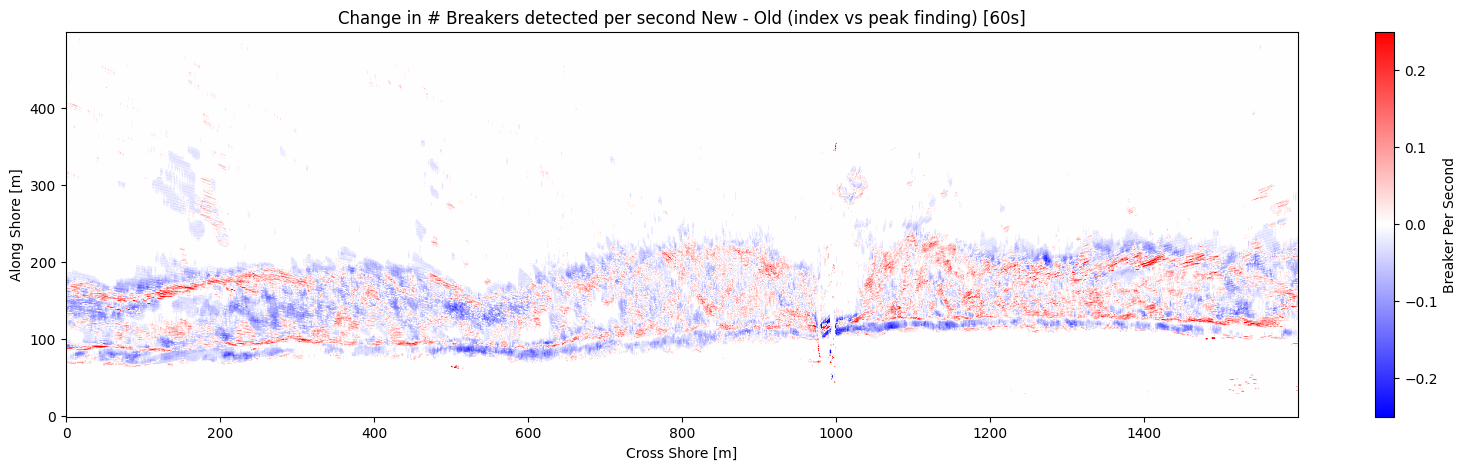

In [90]:
plt.figure(figsize=(20, 5))
plt.imshow((count32_150_new - count32_150_old).T/150, cmap='bwr', vmin=-0.25, vmax=0.25)
plt.colorbar(label='Breaker Per Second')
plt.xlabel('Cross Shore [m]')
plt.ylabel('Along Shore [m]')
plt.title('Change in # Breakers detected per second New - Old (index vs peak finding) [150s]')

plt.figure(figsize=(20, 5))
plt.imshow((count32_60_new - count32_60_old).T/60, cmap='bwr', vmin=-0.25, vmax=0.25)
plt.colorbar(label='Breaker Per Second')
plt.xlabel('Cross Shore [m]')
plt.ylabel('Along Shore [m]')
plt.title('Change in # Breakers detected per second New - Old (index vs peak finding) [60s]')
'''
takeaways: more contentrated peaks, (less foam?) & less swash, more shore break'''


Text(0.5, 1.0, 'Change in # Breakers detected per second 150s-60s')

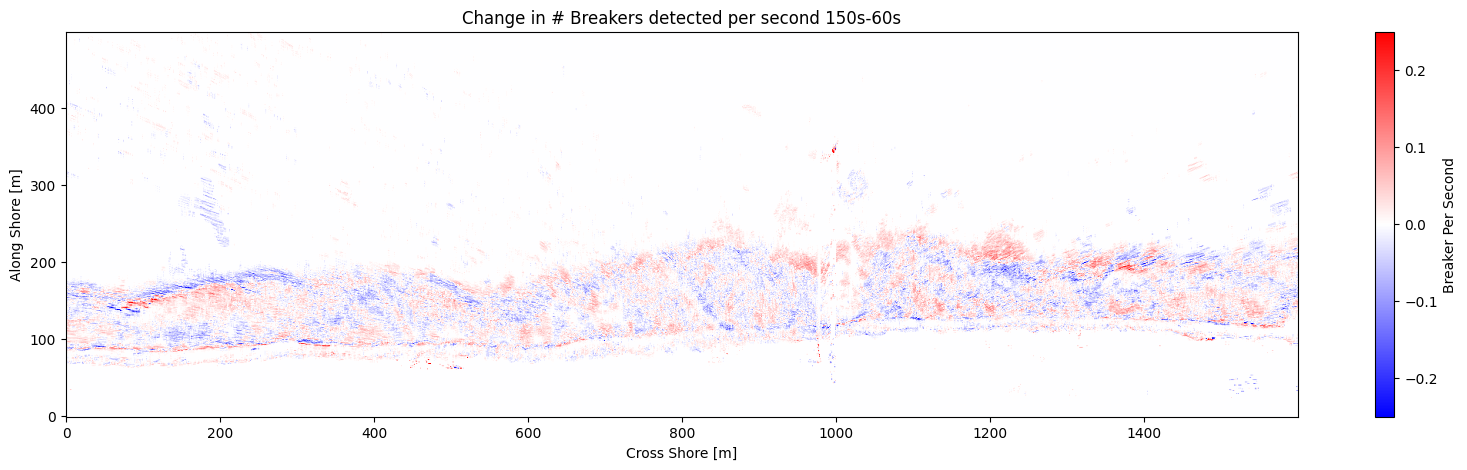

In [91]:
plt.figure(figsize=(20, 5))
plt.imshow((count32_150_new/150 - count32_60_new/60).T, cmap='bwr', vmin=-0.25, vmax=0.25)
plt.colorbar(label='Breaker Per Second')
plt.xlabel('Cross Shore [m]')
plt.ylabel('Along Shore [m]')
plt.title('Change in # Breakers detected per second 150s-60s')

## Other Stuff

6.456495550475761


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/2955583782.py:63: RuntimeWarning: divide by zero encountered in divide
  breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/2955583782.py:63: RuntimeWarning: invalid value encountered in divide
  breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)


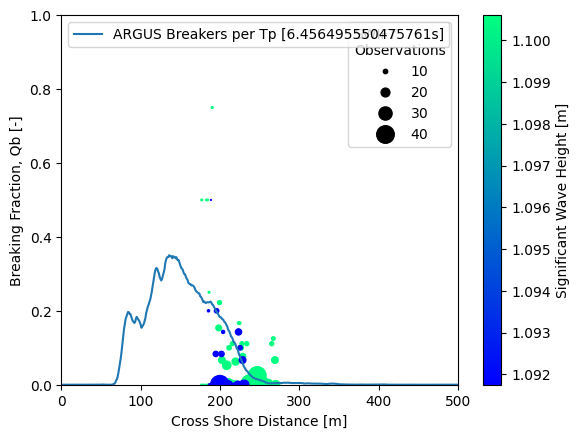

In [27]:
# Load the wave realization dataset
wave_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/wave_realizations_df.csv')
# Load the breaker dataset
breaker_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/breaker_df.csv')
# Load the mission dataset
mission_df = pd.read_csv('/Users/mleclair/Dropbox/phd/code/dunex/drifters/DUNEXMainExp/analysis/../microSWIFT_data/mission_df.csv')

Tp = mission_df[(mission_df['mission number'] == 32)]['Tm [s]'].item()
print(Tp)

# Organize the waves into Cross shore Distance Bins
mission_list = wave_df['mission number'].drop_duplicates()

# Define Cross Shore Bin Size
cross_shore_bin_size = 1

cross_shore_bin_centers_all = []
num_waves_in_bin_all = []
num_breakers_in_bin_all = []
breaking_fraction_all = []
hs_mission = []
tm_mission = []
mean_dir_mission = []
id_mission = []

# for mission_num in mission_list:
for mission_num in [31, 32]:
    # mission Specific Dataframes
    wave_df_mission = wave_df[wave_df['mission number'] == mission_num]
    breaker_df_mission = breaker_df[breaker_df['mission number'] == mission_num]
    mission_df_mission = mission_df[mission_df['mission number'] == mission_num]

    cross_shore_min = wave_df_mission['cross shore location [m]'].min()
    cross_shore_max = wave_df_mission['cross shore location [m]'].max()
    cross_shore_num_bins = int(np.floor((cross_shore_max - cross_shore_min)/ \
                                    cross_shore_bin_size))

    cross_shore_bin_edges = np.linspace(cross_shore_min, cross_shore_max,
                                        cross_shore_num_bins)

    cross_shore_bin_centers = (cross_shore_bin_edges[1:] + \
                           cross_shore_bin_edges[:-1]) / 2

    wave_heights_in_bins = []
    num_waves_in_bin = []
    for n in range(cross_shore_bin_centers.size):
        df = wave_df_mission[wave_df_mission['cross shore location [m]'].between(cross_shore_bin_edges[n], 
                                                                cross_shore_bin_edges[n+1])]
        wave_heights_in_bins.append(df['height [m]'])
        num_waves_in_bin.append(len(df.index))

    num_breakers_in_bin = []
    for n in range(cross_shore_bin_centers.size):
        df = breaker_df_mission[breaker_df_mission['cross shore location [m]'].between(cross_shore_bin_edges[n], 
                                                                cross_shore_bin_edges[n+1])]
        num_breakers_in_bin.append(len(df.index))

    cross_shore_bin_centers_all.append(cross_shore_bin_centers)
    num_waves_in_bin_all.append(num_waves_in_bin)
    num_breakers_in_bin_all.append(num_breakers_in_bin)

    # Compute breaking fraction
    breaking_fraction = np.array(num_breakers_in_bin)/np.array(num_waves_in_bin)
    breaking_fraction_all.append(breaking_fraction)

    # Add mission params
    hs_mission.append(mission_df_mission['Hs [m]'].iloc[0] * np.ones(breaking_fraction.size))
    tm_mission.append(mission_df_mission['Tm [s]'].iloc[0] * np.ones(breaking_fraction.size))
    mean_dir_mission.append(mission_df_mission['Mean Dir [deg]'].iloc[0] * np.ones(breaking_fraction.size))
    id_mission.append(mission_df_mission['mission number'].iloc[0] * np.ones(breaking_fraction.size))


cross_shore_bin_centers_all = np.concatenate(cross_shore_bin_centers_all)
breaking_fraction_all = np.concatenate(breaking_fraction_all)
hs_mission = np.concatenate(hs_mission)
tm_mission = np.concatenate(tm_mission)
mean_dir_mission = np.concatenate(mean_dir_mission)
id_mission = np.concatenate(id_mission)


fig, ax = plt.subplots()
sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all, 
                # c=id_mission, 
                c=hs_mission,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='winter', label='In Situ Qb')
cbar = fig.colorbar(sc)
cbar.set_label('Significant Wave Height [m]')
# cbar.set_label('Mission ID')
ax.set_ylim(0, 1)
ax.set_xlabel('Cross Shore Distance [m]')
ax.set_ylabel('Breaking Fraction, Qb [-]')
ax.set_xlim(0, 500)
scale = 1
l = ax.plot((count32_150.T[0:800, :]/(150/Tp)/scale).mean(axis=1), label=f'Breakers per Tp [{Tp}s]')
elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=1, title='SWIFT\nObservations')
plt.legend(l, [f'ARGUS Breakers per Tp [{Tp}s]'], loc=2)
plt.gca().add_artist(legend1)

# plt.legend(elements + l,  + [f'Breakers per Tp [{Tp}s]'])

# plt.xlabel('Cross-shore meters')
# plt.ylabel('Average Breaker Density')


(174.0394992922184, 270.2434838577755)

In [221]:
hs = []
for h in [heights.values for heights in wave_heights_in_bins]:
    hs += h.tolist()
len(hs)/2

222.5

In [303]:
174.0394992922184, 270.2434838577755
hs = xr.load_dataset('../../model/output/hs32.nc')
hs.Hwave.shape

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/core/indexing.py:630: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


(1001, 901)

Text(0.5, 1.0, 'SWIFT vs. COAWST Hs')

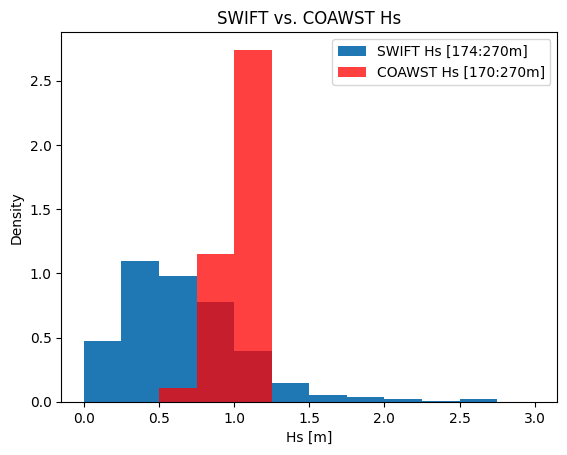

In [333]:
plt.hist(np.concatenate([heights.values for heights in wave_heights_in_bins]), density=True, 
         label=f'SWIFT Hs [{np.min(cross_shore_bin_centers_all):.0f}:{np.max(cross_shore_bin_centers_all):.0f}m]', bins=np.linspace(0, 3, 13))
plt.hist(hs.Hwave[:, 170:270].values.flatten(), density=True, color='r', label='COAWST Hs [170:270m]',bins=np.linspace(0, 3, 13), alpha=0.75)
plt.ylabel('Density')
plt.xlabel('Hs [m]')
plt.legend()
plt.title('SWIFT vs. COAWST Hs')


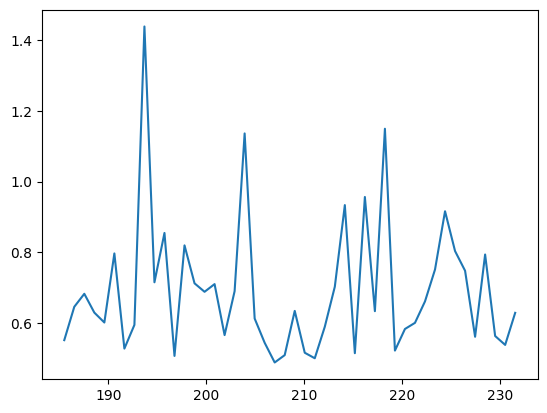

In [224]:
plt.plot(
    cross_shore_bin_centers,
    [heights.values.mean() for heights in wave_heights_in_bins])

hs = xr.load_dataset('../../model/output/hs32.nc')
plt.plot(hs.values.mean(axis=0))

In [374]:
bathy = xr.load_dataset('../../model/code/bathy/ocean_dunex_grd32.nc')
bathy['h'].values[bathy.h.values <= 0] = np.nan
D = (-bathy.h.sel(eta_rho=400))
missions = pd.read_csv('../../data/mission_df.csv')
mission = missions[missions['mission number']==32]

H_s = mission['Hs [m]'].item()
H_rms = H_s / 1.42 # TG89
N = 17 * 60 / mission['Tm [s]'].item() # TG89
H_max = (np.log(N)**0.5 +
         (0.2886 * np.log(N)**-0.5))*H_rms # TG89 (Cartwright and Longuet-Higgins 56)
H = np.linspace(0, H_max, 100)
p = lambda H: 2*H / H_rms**2 * np.exp(-(H/H_rms)**2)
h = D.values
n = 4
gamma = 0.35

w = lambda H: np.minimum((H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)), 1)
pb =  lambda H: p(H)[:, np.newaxis] * w((np.ones(901)[:, np.newaxis] * H[np.newaxis, :]).T)


QB = np.zeros_like(bathy.h.values)
for i in range(1001):
    D = -(bathy.h.isel(eta_rho=i) + mission['water level [m]'].item())
    h = D.values
    w = lambda H: np.minimum(
        (H_rms/gamma/h)**n * (1 - np.exp(-(H/gamma/h)**2)),
        1)
    p = lambda H: 2*H / H_rms**2 * np.exp(-(H/H_rms)**2)
    pb = p(H)[:, np.newaxis] * w((np.ones(901)[:, np.newaxis] * H[np.newaxis, :]).T) # waves, cross-shore
    QB[i, :] = np.mean(pb, axis=0) # Averaged over waves 


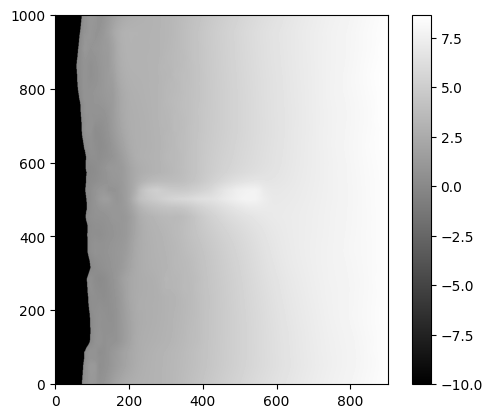

In [375]:
b = bathy.h.values
b[np.isnan(b)] = -10
plt.imshow(b)
plt.colorbar()

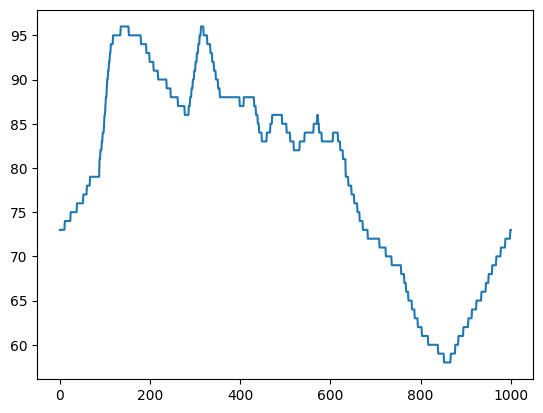

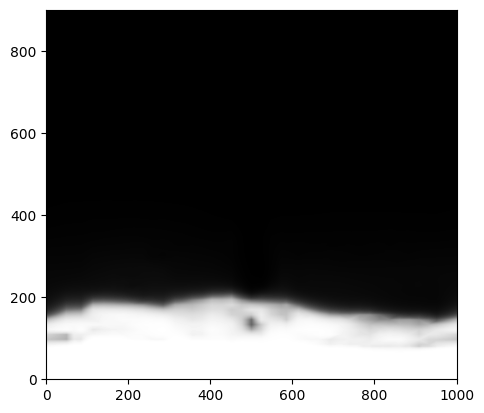

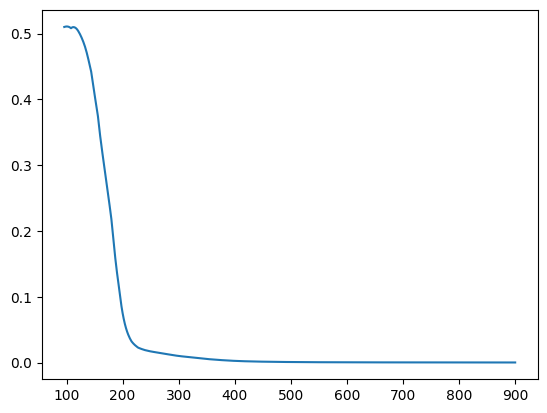

In [386]:
plt.plot(np.argmin(b**2, axis=1))


shoreline = []
qb_unified = []
for i in range(b.shape[0]):
    sl = rising_edge(b[i, :]**2, 1)[0]
    shoreline.append(sl)
    c = np.zeros((901, 1))
    c[:(QB.shape[1]-sl), :] = QB[i, sl:, np.newaxis]
    qb_unified.append(c)
unified = np.array(qb_unified).squeeze().T
mean_shoreline = int(np.mean(shoreline))

plt.figure()
plt.imshow(unified)
plt.figure()
plt.plot(unified.mean(1))

In [33]:
qb = xr.load_dataset('../../model/output/qb32.nc')

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/xarray/core/indexing.py:630: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/542019192.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all,
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/542019192.py:45: RuntimeWarning: Mean of empty slice
  np.nanmean(QB, axis=0), label='TG \'89 Qb'


Text(0.5, 1.0, 'Missions 31/32\n2021-10-13')

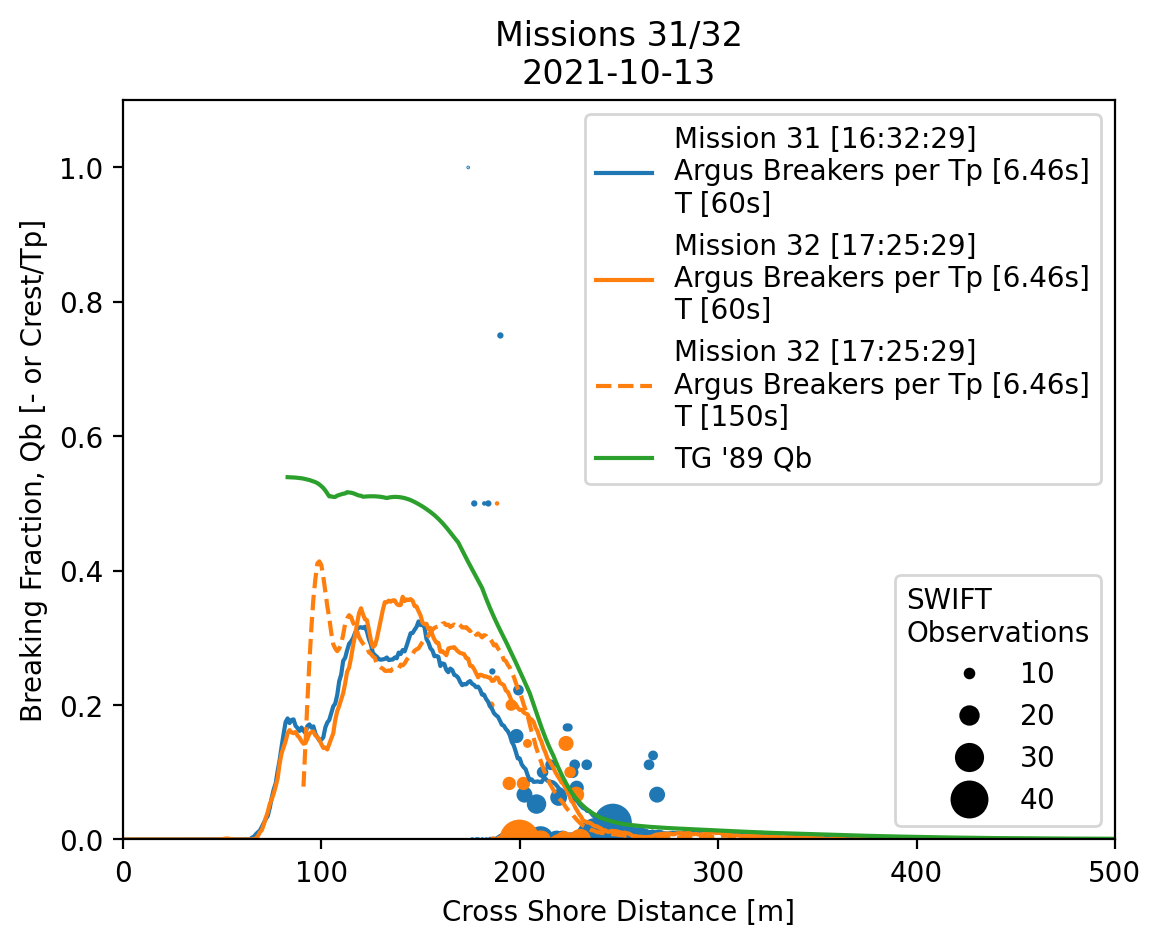

In [354]:
fig, ax = plt.subplots(dpi=200)
mission_colors = list(map(lambda x: plt.cm.tab10.colors[int(x)], id_mission-31))
sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all, 
                c=mission_colors, 
                # c=m,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='tab10', label='In Situ Qb')
# cbar = fig.colorbar(sc)
cbar.set_label('Significant Wave Height [m]')
cbar.set_label('Mission ID')
ax.set_ylim(0, 1.1)
ax.set_xlabel('Cross Shore Distance [m]')
ax.set_ylabel('Breaking Fraction, Qb [- or Crest/Tp]')
ax.set_xlim(0, 500)
scale = 1

l = ax.plot(
    (count31_60.T[:, :]/(60/Tp)*scale).mean(axis=1)
    , label=f'Mission 31 [{mission_df[mission_df['mission number']==31].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')
l = ax.plot(
    (count32_60.T[:, :]/(60/Tp)*scale).mean(axis=1),
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')
# l = ax.plot(
#     (count32_150.T[:, :]/(150/Tp)*scale).mean(axis=1),
#     label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{150}s]',
#     c='tab:orange', linestyle='--')


l = ax.plot(
    np.arange(mean_shoreline, 500),
    unified[:-mean_shoreline]/150*Tp,
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{150}s]',
    c='tab:orange', linestyle='--')

start = 0
# l = ax.plot(
#     np.linspace(start, 500 + start - 1, 500),
#     np.nanmean(qb.Wave_break, axis=0)[0:500],
#     label='COAWST/SWAN Qb'
# )
start = 25

ax.plot(
    np.linspace(start, 900 + start, 901),
    np.nanmean(QB, axis=0), label='TG \'89 Qb'
)

elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=4, title='SWIFT\nObservations')
h, l = ax.get_legend_handles_labels()
plt.legend(h[1:], l[1:], loc=1)
plt.gca().add_artist(legend1)
plt.title(f'Missions 31/32\n{mission_df[mission_df['mission number']==32].time.item()[:10]}')


Text(0.5, 0.95, 'Mission 32 Argus Breaker Density [Tp=6.5s, T=150s]')

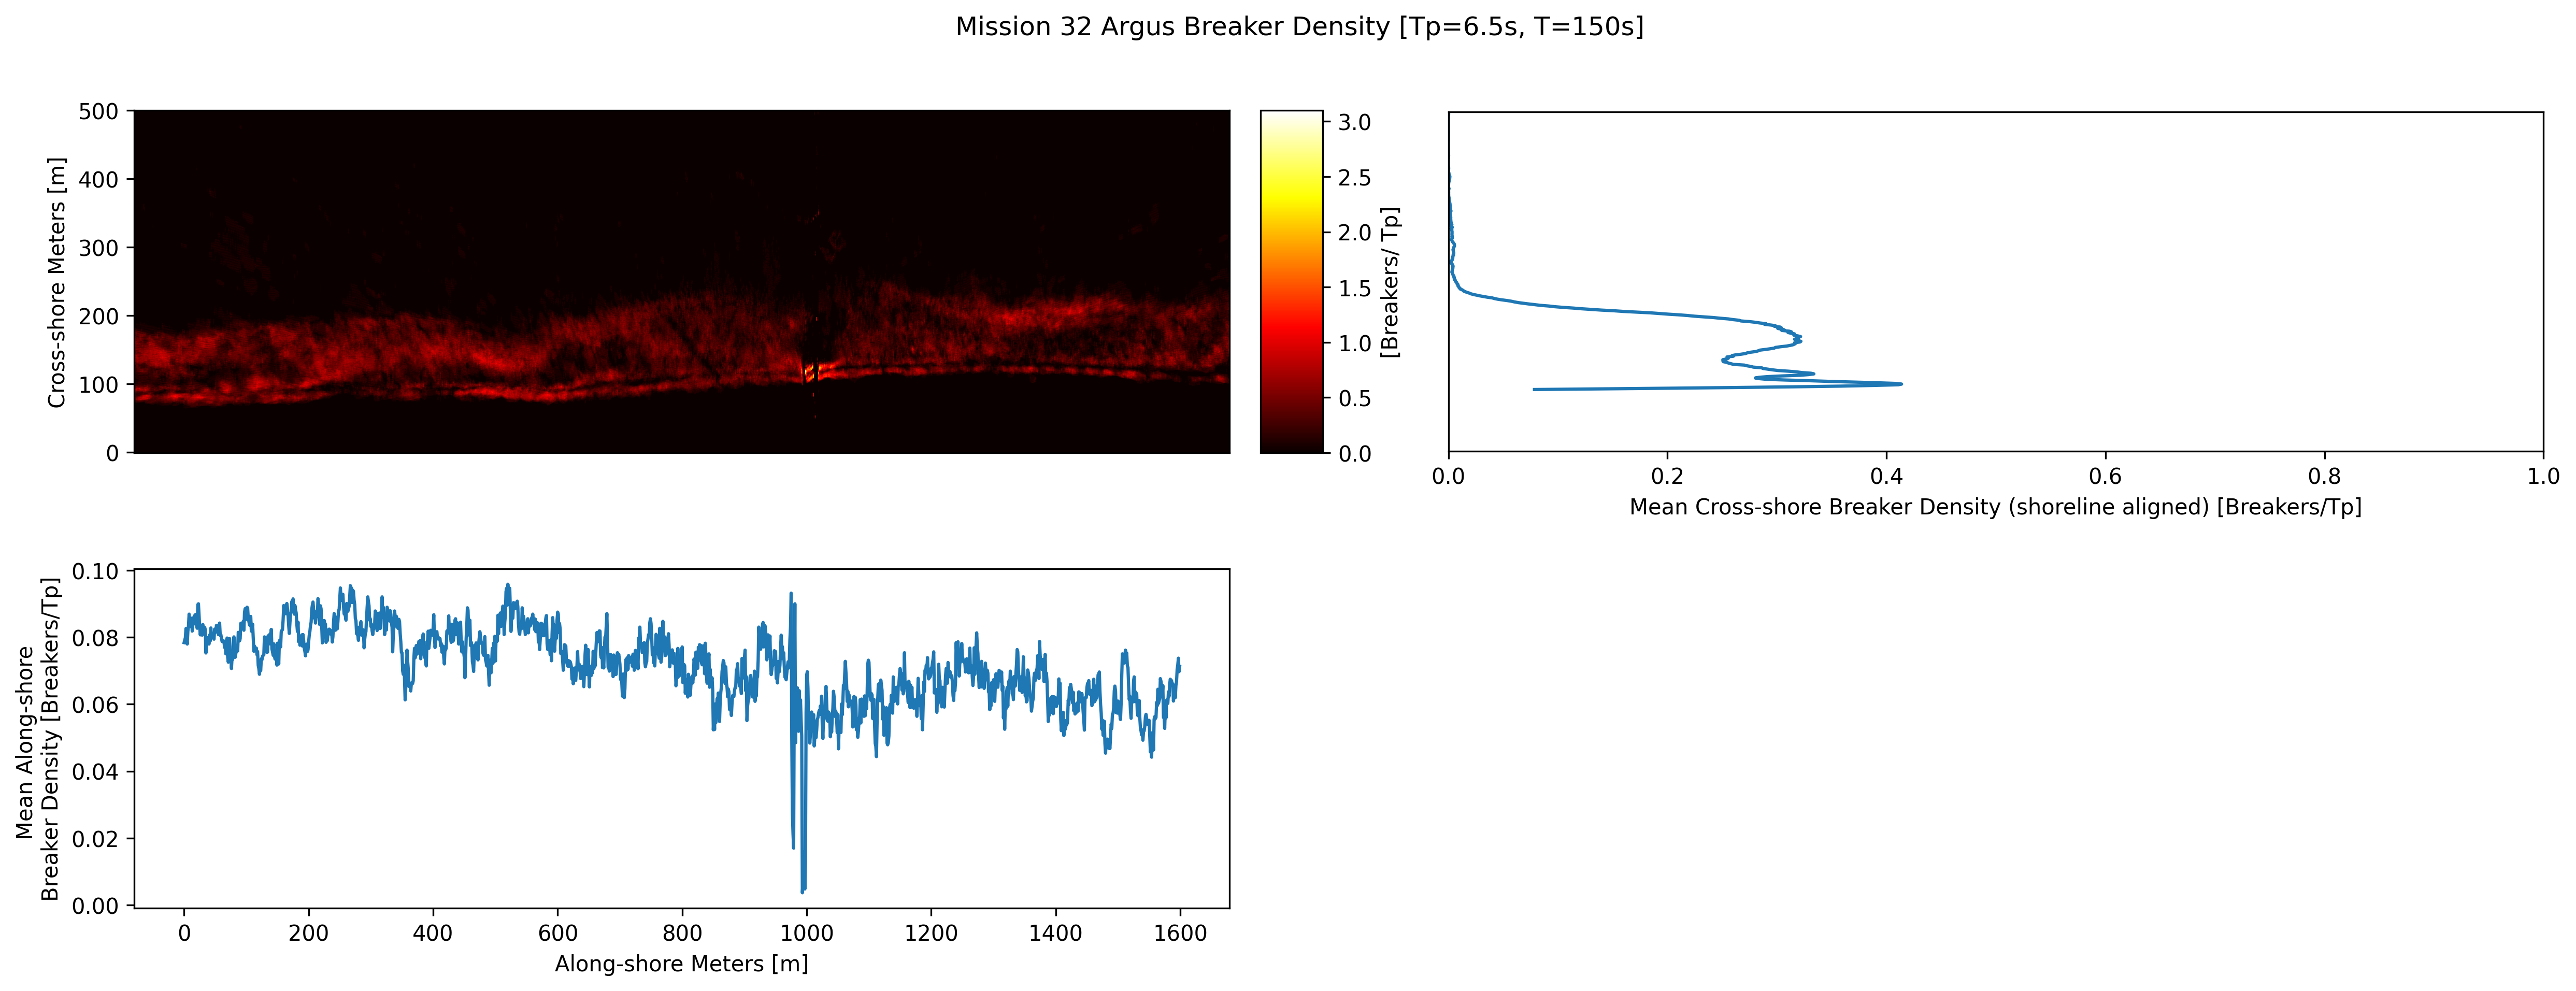

In [401]:
T = 150
Tp = mission_df[(mission_df['mission number'] == 32)]['Tm [s]'].item()

#####################################
fig, axs = plt.subplots(2,2,figsize=(20, 7), dpi=300)
ax = axs[0][0]
ax.set_aspect(1)
im = ax.imshow(count32_150.T/(T/Tp)/scale, cmap='hot') # Breaker Density Per Peak Period
# ax.imshow(scipy.ndimage.gaussian_filter(count.T/(T/Tp)/2/c, sigma=(2,2)), cmap='viridis') # Breaker Density Per Peak Period
# ax.pcolormesh(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=2), cmap='jet') # Breaker Density Per Peak Period
# ax.pcolormesh(*np.mgrid[0:1600, 0:500], (count/(T/Tp)), cmap='jet') # Breaker Density Per Peak Period
# ax.contourf(*np.mgrid[0:1600, 0:500], np.log10(1e-3+ scipy.ndimage.gaussian_filter((count/(T/Tp)), sigma=1)/scale), cmap='Reds', levels=10) # Breaker Density Per Peak Period
ax.set_ylabel('Cross-shore Meters [m]')
# im = ax.contourf(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count/(T/Tp)/scale), sigma=1), cmap='hot', levels=50) # Breaker Density Per Peak Period
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax, label=f'[Breakers/ Tp]')
ax.set_xticks([])
ax.set_yticks(np.linspace(0, 500, 6))
# ax.arrow(1500, 400, -100, 0, width=5, color='r')
# ax.text(1410, 425, "FRF Y", color='r')
#####################################
ax = axs[1][0]
ax.plot((count32_150.T/(T/Tp)/scale).mean(axis=0))
ax.set_ylabel('Cumulative Breaker Density')
xvals,yvals = ax.get_xlim(),ax.get_ylim()
xrange = xvals[1]-xvals[0]
yrange = yvals[1]-yvals[0]
ax.set_aspect(0.31*(xrange/yrange), adjustable='box')
ax.set_xlabel('Along-shore Meters [m]')
ax.set_ylabel(f'Mean Along-shore \nBreaker Density [Breakers/Tp]')
#####################################
ax = axs[0][1]
ax.plot(
    unified[:-mean_shoreline]/150*Tp,
    np.arange(mean_shoreline, 500)
)
# ax.plot((count32_150.T[:, :]/(T/Tp)/scale).mean(axis=1), np.linspace(0, 499, 500))
ax.set_xlim(0, 1)
ax.set_ylim(0, 500)
ax.set_xticks(np.linspace(0, 1, 6), labels=[f'{x:.1f}' for x in np.linspace(0, 1, 6)])
xvals,yvals = ax.get_xlim(),ax.get_ylim()
ax.set_yticks([])
xrange = xvals[1]-xvals[0]
yrange = yvals[1]-yvals[0]
ax.set_aspect(0.31*(xrange/yrange), adjustable='box')
ax.set_xlabel(f'Mean Cross-shore Breaker Density (shoreline aligned) [Breakers/Tp]')

axs[1][1].set_visible(False)
fig.suptitle(f'Mission 32 Argus Breaker Density [Tp={Tp:.1f}s, T=150s]', y=0.95)

In [294]:
 mean_shoreline

91

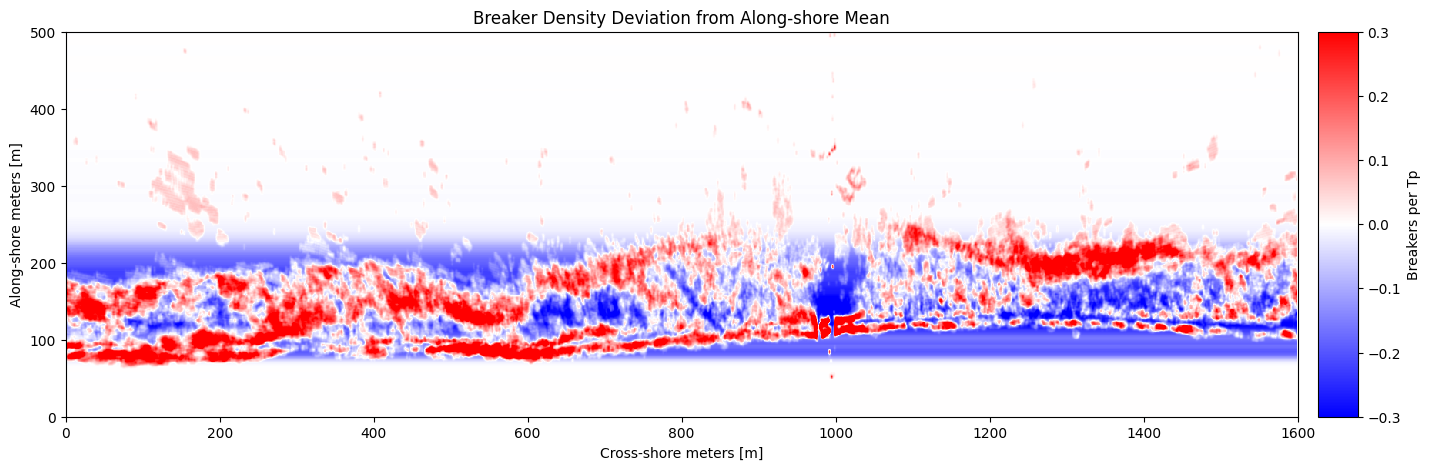

In [202]:
fig, ax = plt.subplots(1,1, figsize=(20, 5))
im = ax.pcolormesh(*np.mgrid[0:1600, 0:500], scipy.ndimage.gaussian_filter((count32_150/(T/Tp)/scale), sigma=1)
                 -(count32_150.T[:, :]/(T/Tp)/scale).mean(axis=1) , cmap='bwr', vmin=-0.3, vmax=0.3)
#levels=np.linspace(-0.25, 0.25, 21)) # Breaker Density Per Peak Period
plt.xlim(0, 1600)
plt.title('Breaker Density Deviation from Along-shore Mean')
plt.ylim(0, 500)
plt.ylabel('Along-shore meters [m]')
plt.xlabel('Cross-shore meters [m]')
plt.gca().set_aspect(1)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax, label='Breakers per Tp')


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3082851393.py:1: RuntimeWarning: Mean of empty slice
  mqb = np.nanmean(qb.Wave_break, 0)[:500]
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3082851393.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean(QB, axis=0), label='TG \'89 Qb'


Text(0.5, 0, 'Cum Qb')

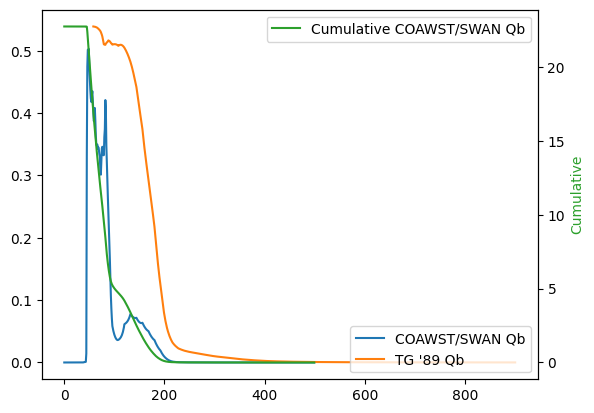

In [105]:
mqb = np.nanmean(qb.Wave_break, 0)[:500]
mqb[np.isnan(mqb)] = 0
plt.plot(mqb, label='COAWST/SWAN Qb')
plt.plot(
   np.linspace(start, 900 + start, 901),
   np.nanmean(QB, axis=0), label='TG \'89 Qb'
)
plt.legend(loc=4)

# plt.twinx().plot(
#     np.linspace(start, 500 + start - 1, 500),
#     np.cumsum(mqb[::-1])[::-1],
#     label='Cumulative COAWST/SWAN Qb', c='tab:green'
# )
plt.ylabel('Cumulative', c='tab:green')

plt.legend(loc=1)

# plt.ylim(0, 20)
plt.xlabel('Cross Shore [m]')
plt.xlabel('Cum Qb')


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3634692867.py:3: RuntimeWarning: Mean of empty slice
  h=np.nanmean(bathy.h.values, axis=0)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3634692867.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3634692867.py:33: RuntimeWarning: Mean of empty slice
  np.nanmean(qb.Wave_break, axis=0)[:500],
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3634692867.py:39: RuntimeWarning: Mean of empty slice
  np.nanmean(QB, axis=0)[:500], label='TG \'89 Qb'


Text(0.5, 1.0, 'Missions 31/32\n2021-10-13')

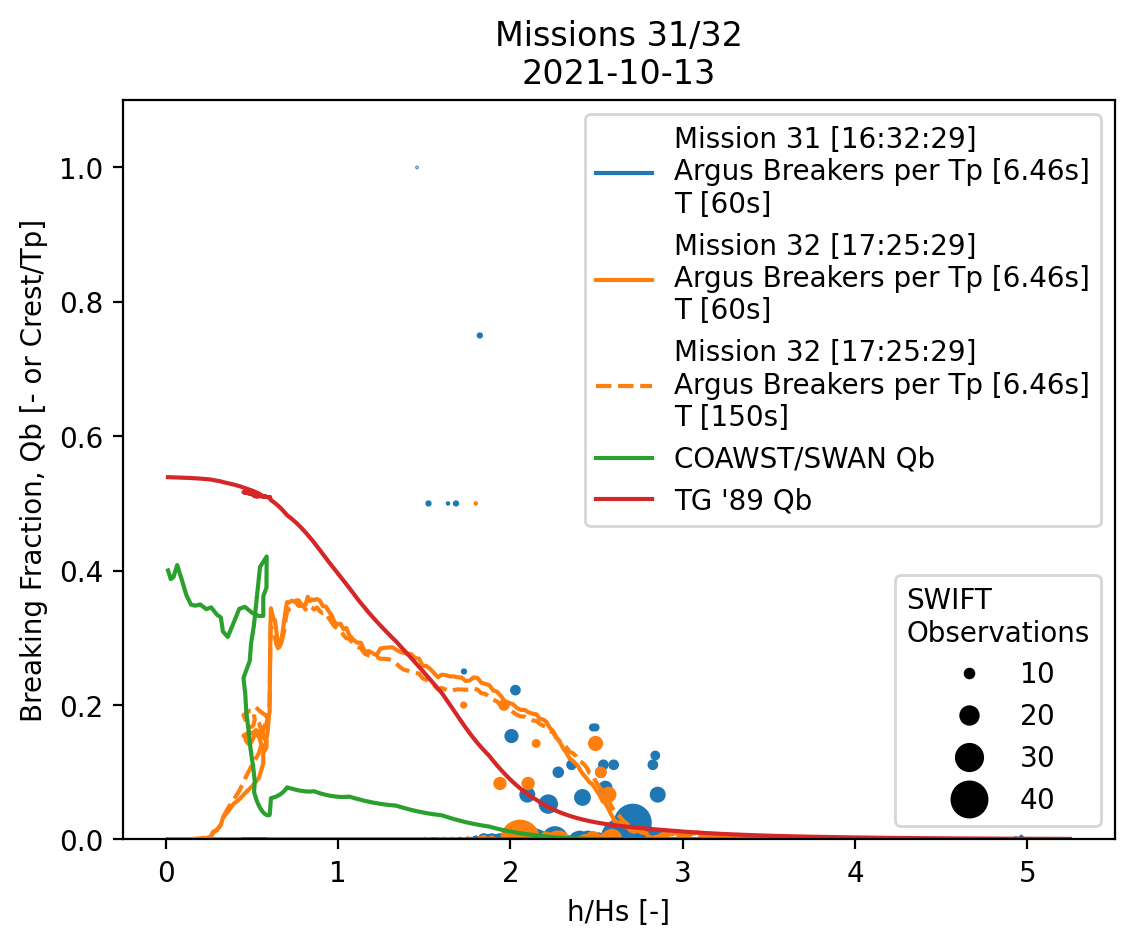

In [116]:
fig, ax = plt.subplots(dpi=200)
mission_colors = list(map(lambda x: plt.cm.tab10.colors[int(x)], id_mission-31))
h=np.nanmean(bathy.h.values, axis=0)
sc = ax.scatter(
                np.interp(cross_shore_bin_centers_all, np.arange(500), h[:500])/hs_mission, breaking_fraction_all, 
                c=mission_colors, 
                # c=m,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='tab10', label='In Situ Qb')
ax.set_ylim(0, 1.1)
ax.set_xlabel('h/Hs [-]')
ax.set_ylabel('Breaking Fraction, Qb [- or Crest/Tp]')
# ax.set_xlim(0, 500)
scale = 1

l = ax.plot(
    h[:500]/mission_df[mission_df['mission number']==31]['Hs [m]'].item(),
    (count31_60.T[:, :]/(60/Tp)*scale).mean(axis=1)
    , label=f'Mission 31 [{mission_df[mission_df['mission number']==31].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')
l = ax.plot(
    h[:500]/mission_df[mission_df['mission number']==32]['Hs [m]'].item(),
    (count32_60.T[:, :]/(60/Tp)*scale).mean(axis=1),
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')


l = ax.plot(
    h[:500]/mission_df[mission_df['mission number']==32]['Hs [m]'].item(),
    (count32_150.T[:, :]/(150/Tp)*scale).mean(axis=1),
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{150}s]',
    c='tab:orange', linestyle='--')

start = 0
l = ax.plot(
    h[:500]/mission_df[mission_df['mission number']==32]['Hs [m]'].item(),
    np.nanmean(qb.Wave_break, axis=0)[:500],
    label='COAWST/SWAN Qb'
)
start = 0
ax.plot(
    h[:500]/mission_df[mission_df['mission number']==32]['Hs [m]'].item(),
    np.nanmean(QB, axis=0)[:500], label='TG \'89 Qb'
)

elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=4, title='SWIFT\nObservations')
h, l = ax.get_legend_handles_labels()
plt.legend(h[1:], l[1:], loc=1)
plt.gca().add_artist(legend1)
plt.title(f'Missions 31/32\n{mission_df[mission_df['mission number']==32].time.item()[:10]}')


In [ ]:
### Shoreline alignment

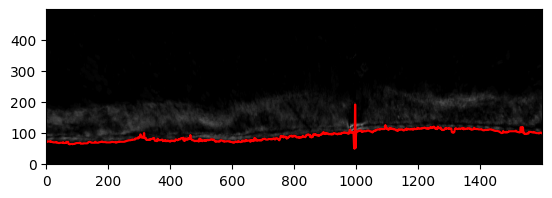

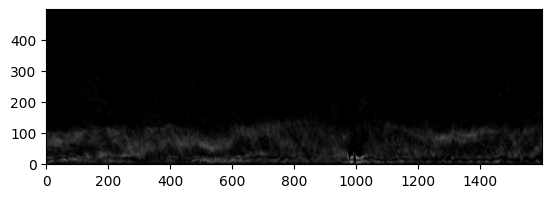

In [388]:
def rising_edge(data, thresh):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == 1)[0]
    return pos

plt.imshow(count32_150.T)
shoreline = []
count_unified = []
for i in range(count32_150.shape[0]):
    sl = rising_edge(count32_150[i, :], 1)[0]
    shoreline.append(sl)
    c = np.zeros((500, 1))
    c[:(count32_150.shape[1]-sl), :] = count32_150[i, sl:, np.newaxis]
    count_unified.append(c)
plt.plot(shoreline, c='r')
plt.figure()
plt.imshow(np.array(count_unified).squeeze().T)

Text(0.5, 1.0, 'Deviation from Shoreline Corrected Mean Breaker Density')

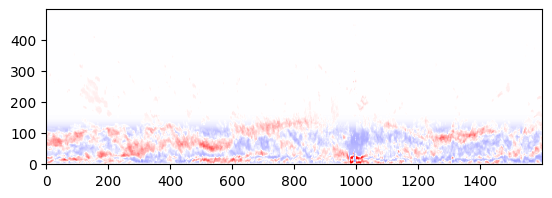

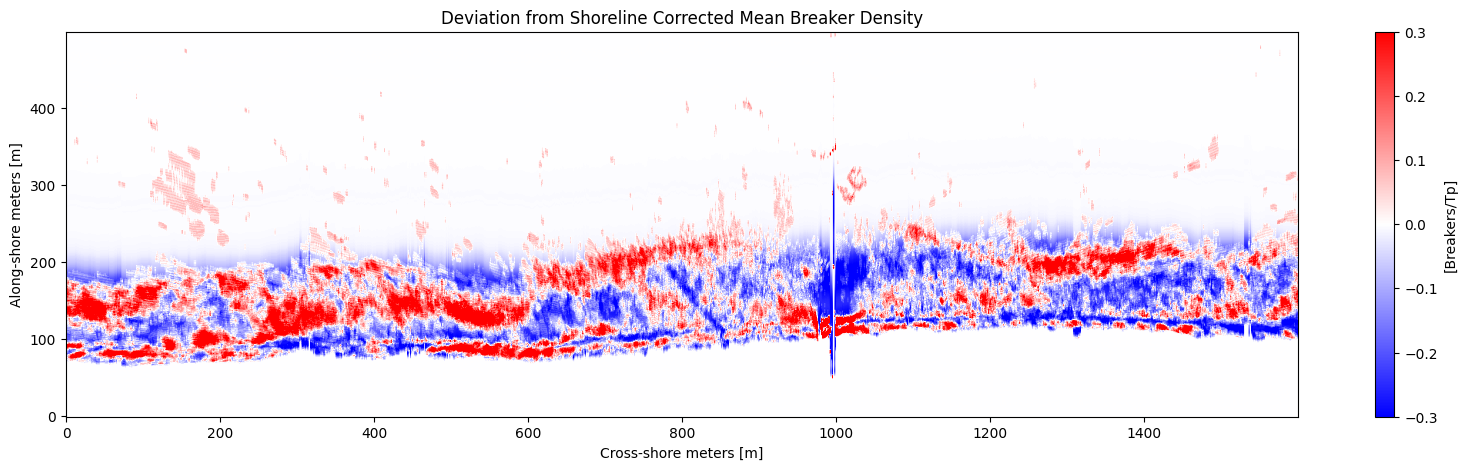

In [350]:
bn_count = np.array(count_unified).squeeze() / 150 * Tp
bn_count -= bn_count.mean(axis=0)
plt.imshow(bn_count.T, vmin=-1, vmax=1, cmap='bwr')
bn_count_undone = []
for i in range(count32_150.shape[0]):
    sl = shoreline[i]
    c = np.zeros((500, 1))
    c[sl:, :] = bn_count[i, :bn_count.shape[1]-sl, np.newaxis]
    bn_count_undone.append(c)
plt.figure(figsize=(20, 5))
plt.imshow(np.array(bn_count_undone).squeeze().T, vmin=-0.3, vmax=0.3, cmap='bwr')
plt.colorbar(label='[Breakers/Tp]')
plt.xlabel('Cross-shore meters [m]')
plt.ylabel('Along-shore meters [m]')
plt.title('Deviation from Shoreline Corrected Mean Breaker Density')

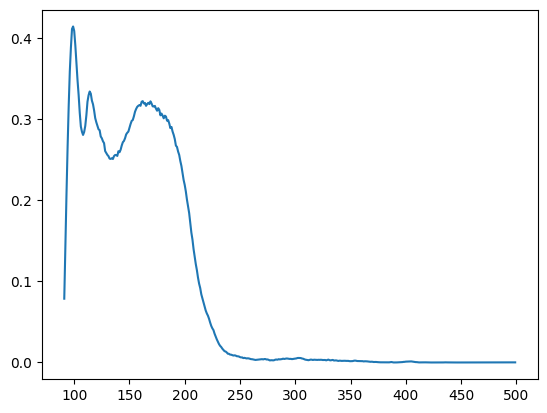

In [389]:
unified = np.array(count_unified).squeeze().T.mean(1)
mean_shoreline = int(np.mean(shoreline))
plt.plot(
    np.arange(mean_shoreline, 500), 
    unified[:-mean_shoreline]/150*Tp
    )

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3986760749.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all,
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_50363/3986760749.py:78: RuntimeWarning: Mean of empty slice
  np.nanmean(QB, axis=0), label='TG \'89 Qb'


Text(0.5, 1.0, 'Missions 31/32 (shoreline-aligned)\n2021-10-13')

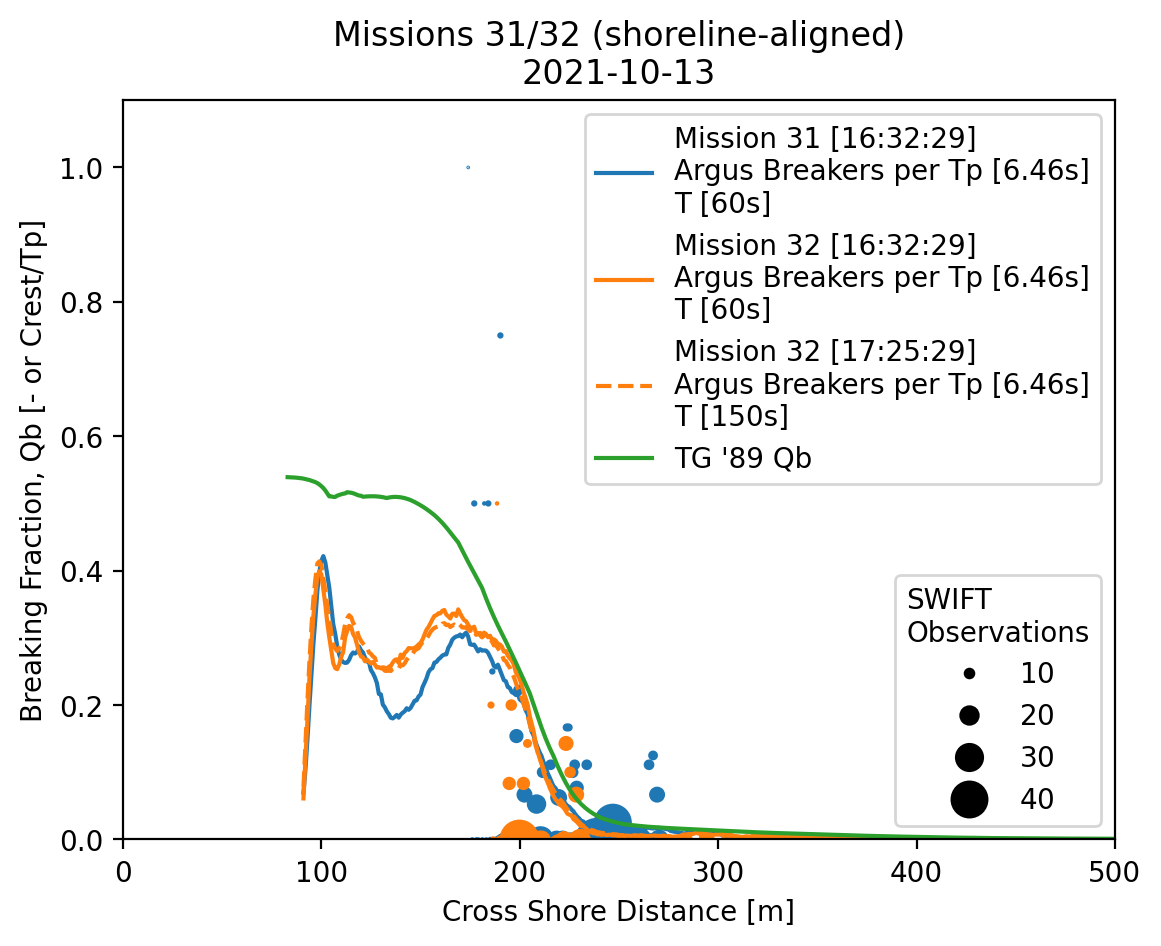

In [358]:

fig, ax = plt.subplots(dpi=200)
mission_colors = list(map(lambda x: plt.cm.tab10.colors[int(x)], id_mission-31))
sc = ax.scatter(cross_shore_bin_centers_all, breaking_fraction_all, 
                c=mission_colors, 
                # c=m,
                s=(np.concatenate(num_waves_in_bin_all))**2/10, 
                cmap='tab10', label='In Situ Qb')
# cbar = fig.colorbar(sc)
cbar.set_label('Significant Wave Height [m]')
cbar.set_label('Mission ID')
ax.set_ylim(0, 1.1)
ax.set_xlabel('Cross Shore Distance [m]')
ax.set_ylabel('Breaking Fraction, Qb [- or Crest/Tp]')
ax.set_xlim(0, 500)
scale = 1


shoreline = []
count_unified = []
for i in range(count31_60.shape[0]):
    sl = rising_edge(count32_150[i, :], 1)[0]
    shoreline.append(sl)
    c = np.zeros((500, 1))
    c[:(count31_60.shape[1]-sl), :] = count31_60[i, sl:, np.newaxis]
    count_unified.append(c)
unified = np.array(count_unified).squeeze().T.mean(1)
mean_shoreline = int(np.mean(shoreline))

l = ax.plot(
    np.arange(mean_shoreline, 500),
    unified[:-mean_shoreline]/60*Tp,
    label=f'Mission 31 [{mission_df[mission_df['mission number']==31].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')


shoreline = []
count_unified = []
for i in range(count31_60.shape[0]):
    sl = rising_edge(count32_150[i, :], 1)[0]
    shoreline.append(sl)
    c = np.zeros((500, 1))
    c[:(count32_60.shape[1]-sl), :] = count32_60[i, sl:, np.newaxis]
    count_unified.append(c)
unified = np.array(count_unified).squeeze().T.mean(1)
mean_shoreline = int(np.mean(shoreline))

l = ax.plot(
    np.arange(mean_shoreline, 500),
    unified[:-mean_shoreline]/60*Tp,
    label=f'Mission 32 [{mission_df[mission_df['mission number']==31].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [60s]')

shoreline = []
count_unified = []
for i in range(count31_60.shape[0]):
    sl = rising_edge(count32_150[i, :], 1)[0]
    shoreline.append(sl)
    c = np.zeros((500, 1))
    c[:(count32_150.shape[1]-sl), :] = count32_150[i, sl:, np.newaxis]
    count_unified.append(c)
unified = np.array(count_unified).squeeze().T.mean(1)
mean_shoreline = int(np.mean(shoreline))

l = ax.plot(
    np.arange(mean_shoreline, 500),
    unified[:-mean_shoreline]/150*Tp,
    label=f'Mission 32 [{mission_df[mission_df['mission number']==32].time.item()[11:-7]}]\nArgus Breakers per Tp [{6.46}s]\nT [{150}s]',
    c='tab:orange', linestyle='--')

start = 0
# l = ax.plot(
#     np.linspace(start, 500 + start - 1, 500),
#     np.nanmean(qb.Wave_break, axis=0)[0:500],
#     label='COAWST/SWAN Qb'
# )
start = 25

ax.plot(
    np.linspace(start, 900 + start, 901),
    np.nanmean(QB, axis=0), label='TG \'89 Qb'
)

elements, labels = sc.legend_elements("sizes", num=5, func=lambda x: np.sqrt(x*10))
legend1 = plt.legend(elements, [f'{l}' for l in labels], loc=4, title='SWIFT\nObservations')
h, l = ax.get_legend_handles_labels()
plt.legend(h[1:], l[1:], loc=1)
plt.gca().add_artist(legend1)
plt.title(f'Missions 31/32 (shoreline-aligned)\n{mission_df[mission_df['mission number']==32].time.item()[:10]}')
